In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
from sklearn.covariance import GraphicalLassoCV
from scipy import stats

plt.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 8)

## 2. 데이터 로딩 및 전처리

In [2]:
data = pd.read_csv("../db/processed_data/total_only_org.csv")
food_groups = data.iloc[:, 35:54]

In [3]:
food_names_en = food_groups.columns
food_groups.columns = food_names_en

health_vars = data[['BMI(kg/m2)', 'Systolic blood pressure (mmHg)',
                    'Diastolic Blood Pressure (mmHg)', 'Total Cholesterol (mg/dL)',
                    'Triglycerides (mg/dL)', 'LDL-C (mg/dL)', 'HDL-C (mg/dL)',
                    'Fasting glucose (mg/dL)']]
health_vars.columns = ['BMI', 'SBP', 'DBP', 'TC', 'TG', 'LDL', 'HDL', 'FG']

mets_components = data[['Increased waist circumference', 'Elevated blood pressure',
                        'Impaired fasting glucose', 'Elevated triglycerides',
                        'Decreased HDL-C', 'MetS']]
mets_components.columns = ['WC', 'U_BP', 'IFG', 'U_TG', 'D_HDL', 'MetS']

combined_data = pd.concat([food_groups, health_vars, mets_components], axis=1)
combined_data = combined_data.dropna()
print(f"데이터 크기: {combined_data.shape}")
    
food_data = combined_data[food_names_en]

데이터 크기: (23040, 33)


In [4]:
# GGM assumes multivariate normality - checking normality for each food variable
from scipy.stats import shapiro, skew, kurtosis
from scipy.special import boxcox1p

print("=== Normality Assessment ===\n")

normality_results = []
for col in food_data.columns:
    # Shapiro-Wilk test (sample subset due to computational cost)
    sample_data = food_data[col].dropna().sample(min(5000, len(food_data)), random_state=42)
    stat, p_value = shapiro(sample_data)
    
    # Skewness and kurtosis
    skewness = skew(food_data[col].dropna())
    kurt = kurtosis(food_data[col].dropna())
    
    normality_results.append({
        'Variable': col,
        'Shapiro_W': stat,
        'Shapiro_p': p_value,
        'Skewness': skewness,
        'Kurtosis': kurt,
        'Normal': 'Yes' if p_value > 0.05 else 'No'
    })

normality_df = pd.DataFrame(normality_results)
print(f"Variables with normal distribution: {(normality_df['Normal'] == 'Yes').sum()}/{len(normality_df)}")
print(f"\nVariables with high skewness (|skew| > 1): {(np.abs(normality_df['Skewness']) > 1).sum()}")
display(normality_df.round(4))

# Apply Box-Cox transformation for highly skewed variables
print("\n=== Applying Transformations ===")
food_data_transformed = food_data.copy()
transformed_vars = []

for col in food_data.columns:
    skewness = normality_df[normality_df['Variable'] == col]['Skewness'].values[0]
    
    # Transform if skewness > 0.75 or < -0.75
    if abs(skewness) > 0.75:
        # Add small constant to handle zeros, then apply Box-Cox transformation
        food_data_transformed[col] = boxcox1p(food_data[col], 0.25)
        transformed_vars.append(col)

print(f"Transformed {len(transformed_vars)} variables with high skewness")
print(f"Transformed variables: {', '.join(transformed_vars[:5])}..." if len(transformed_vars) > 5 else f"Transformed variables: {', '.join(transformed_vars)}")

# Verify transformation effect
print("\n=== Post-Transformation Skewness Check ===")
post_skewness = []
for col in transformed_vars[:5]:  # Show first 5
    original_skew = skew(food_data[col].dropna())
    new_skew = skew(food_data_transformed[col].dropna())
    post_skewness.append({
        'Variable': col,
        'Original_Skewness': original_skew,
        'Transformed_Skewness': new_skew,
        'Improvement': abs(original_skew) - abs(new_skew)
    })

if post_skewness:
    display(pd.DataFrame(post_skewness).round(4))

=== Normality Assessment ===

Variables with normal distribution: 0/19

Variables with high skewness (|skew| > 1): 4


,Variable,Shapiro_W,Shapiro_p,Skewness,Kurtosis,Normal
0,Meal Frequency,0.6530,0.0,-0.9081,-0.9527,No
1,Meal Portion Size,0.6478,0.0,-0.0603,1.3246,No
2,Eating Out Frequency,0.8737,0.0,0.1123,-0.6363,No
3,Rice Portion Size,0.6946,0.0,-0.0554,0.7259,No
4,Snacking Frequency,0.8089,0.0,-0.0479,-1.2402,No
5,Grain Products,0.7897,0.0,-0.1142,-0.6506,No
6,Protein Foods,0.8424,0.0,-0.4268,-0.2983,No
7,Vegetables,0.8690,0.0,-0.3132,-0.6353,No
8,Dairy Products,0.8093,0.0,0.3502,-1.1796,No
9,Fruits,0.8011,0.0,-0.1209,-1.3518,No



=== Applying Transformations ===
Transformed 6 variables with high skewness
Transformed variables: Meal Frequency, Fried Foods, High Fat Meat, Processed Foods, Sugar-Sweetened Beverages...

=== Post-Transformation Skewness Check ===


,Variable,Original_Skewness,Transformed_Skewness,Improvement
0,Meal Frequency,-0.9081,-0.9805,-0.0724
1,Fried Foods,1.5108,1.2295,0.2813
2,High Fat Meat,1.0919,0.7862,0.3057
3,Processed Foods,1.2599,0.9813,0.2786
4,Sugar-Sweetened Beverages,1.7753,1.5002,0.2750


## 2.1 정규성 검정 및 데이터 변환

In [5]:
# Nonparanormal (npn) transformation: rank-based transformation to approximate normality
# This is particularly useful for non-Gaussian dietary data
print("=== Nonparanormal (npn) Transformation ===\n")

def npn_transform(data):
    """
    Nonparanormal transformation using Gaussian copula approach
    Converts data to ranks, then to quantiles of standard normal distribution
    """
    from scipy.stats import norm
    
    transformed_data = data.copy()
    n = len(data)
    
    for col in data.columns:
        # Rank transformation (ties handled by average)
        ranks = data[col].rank(method='average')
        # Convert to [0,1] scale, avoiding 0 and 1 for numerical stability
        ranks_scaled = (ranks - 0.5) / n
        # Apply inverse normal CDF to get normal quantiles
        transformed_data[col] = norm.ppf(ranks_scaled)
    
    return transformed_data

# Choose transformation method: 'boxcox' or 'npn'
TRANSFORMATION_METHOD = 'npn'  # Change to 'boxcox' to use Box-Cox instead

if TRANSFORMATION_METHOD == 'npn':
    print("Using Nonparanormal (npn) transformation")
    food_data_transformed_npn = npn_transform(food_data)
    
    # Verify transformation - all variables should now be approximately normal
    print("\n=== Post-npn Transformation Check (first 5 variables) ===")
    post_npn_check = []
    for col in food_data.columns[:5]:
        original_skew = skew(food_data[col].dropna())
        new_skew = skew(food_data_transformed_npn[col].dropna())
        post_npn_check.append({
            'Variable': col,
            'Original_Skewness': original_skew,
            'npn_Skewness': new_skew,
            'Improvement': abs(original_skew) - abs(new_skew)
        })
    display(pd.DataFrame(post_npn_check).round(4))
    
    # Update food_data_transformed to use npn version
    food_data_transformed = food_data_transformed_npn.copy()
    print(f"\nUsing npn-transformed data for GGM analysis")
    
elif TRANSFORMATION_METHOD == 'boxcox':
    print("Using Box-Cox transformation (already applied in previous cell)")
    # food_data_transformed already created in cell-4

print(f"\nTransformation complete. Proceeding with {TRANSFORMATION_METHOD} transformed data.")

=== Nonparanormal (npn) Transformation ===

Using Nonparanormal (npn) transformation

=== Post-npn Transformation Check (first 5 variables) ===


,Variable,Original_Skewness,npn_Skewness,Improvement
0,Meal Frequency,-0.9081,-0.7973,0.1108
1,Meal Portion Size,-0.0603,-0.0001,0.0602
2,Eating Out Frequency,0.1123,0.0301,0.0822
3,Rice Portion Size,-0.0554,0.0180,0.0374
4,Snacking Frequency,-0.0479,-0.0413,0.0066



Using npn-transformed data for GGM analysis

Transformation complete. Proceeding with npn transformed data.


## 3. Gaussian Graphical Model 구축

## 2.2 Nonparanormal (npn) 변환 (선택적)


=== Graphical Lasso를 이용한 정밀행렬 추정 ===
최적 alpha (정규화 파라미터): 0.0009
정밀행렬 크기: (19, 19)


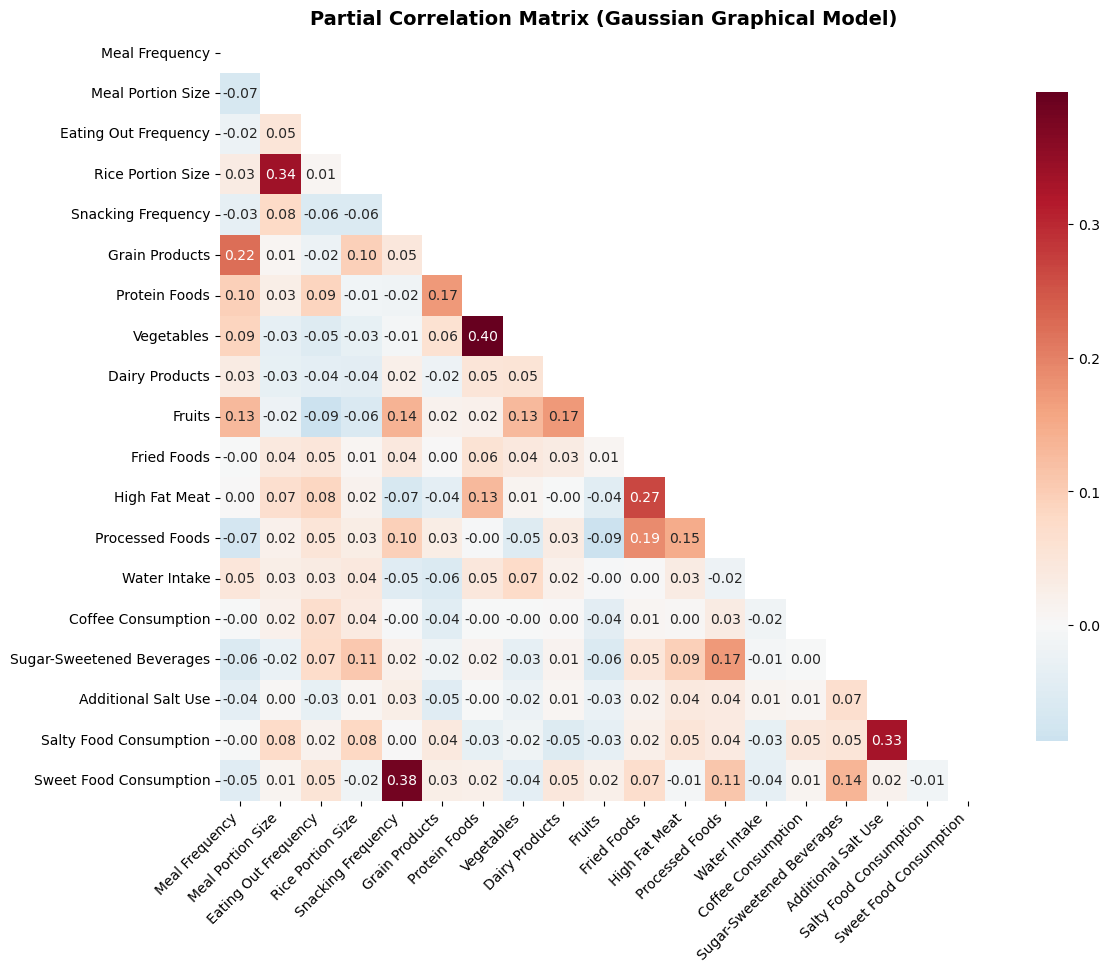


=== Permutation Test for Threshold Determination ===
Running permutation test (this may take a moment)...
  Progress: 20/100
  Progress: 40/100
  Progress: 60/100
  Progress: 80/100
  Progress: 100/100

Permutation-based threshold (95th percentile): 0.0000
Mean null partial correlation: 0.0000
Std null partial correlation: 0.0003

유의한 엣지 수: 169
전체 가능한 엣지 수: 171
네트워크 밀도: 0.988

네트워크 생성 완료: 19개 노드, 169개 엣지
평균 엣지 가중치: 0.053
연결된 구성요소 수: 1


In [6]:
# Data standardization for GGM (using transformed data)
scaler = StandardScaler()
food_data_scaled = scaler.fit_transform(food_data_transformed)
food_data_scaled_df = pd.DataFrame(food_data_scaled, columns=food_data_transformed.columns)

# Gaussian Graphical Model using Graphical Lasso
print("\n=== Graphical Lasso를 이용한 정밀행렬 추정 ===")
gl_cv = GraphicalLassoCV(cv=5, max_iter=1000, tol=1e-4, n_jobs=-1)
gl_cv.fit(food_data_scaled)

precision_matrix = gl_cv.precision_
partial_corr_matrix = -precision_matrix / np.sqrt(np.outer(np.diag(precision_matrix), np.diag(precision_matrix)))
np.fill_diagonal(partial_corr_matrix, 1)

print(f"최적 alpha (정규화 파라미터): {gl_cv.alpha_:.4f}")
print(f"정밀행렬 크기: {precision_matrix.shape}")

# 편상관계수 행렬 시각화
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(partial_corr_matrix, dtype=bool))
sns.heatmap(partial_corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            square=True, fmt='.2f', cbar_kws={"shrink": .8},
            xticklabels=food_data_transformed.columns, yticklabels=food_data_transformed.columns)
plt.title('Partial Correlation Matrix (Gaussian Graphical Model)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Permutation-based threshold for statistical significance
print("\n=== Permutation Test for Threshold Determination ===")
n_permutations = 100
n_vars = food_data_scaled.shape[1]
n_samples = food_data_scaled.shape[0]

# Collect null distribution of partial correlations
null_partial_corrs = []

print("Running permutation test (this may take a moment)...")
for i in range(n_permutations):
    if (i + 1) % 20 == 0:
        print(f"  Progress: {i+1}/{n_permutations}")
    
    # Permute each variable independently to break relationships
    permuted_data = np.copy(food_data_scaled)
    for j in range(n_vars):
        permuted_data[:, j] = np.random.permutation(permuted_data[:, j])
    
    # Fit Graphical Lasso on permuted data
    try:
        gl_perm = GraphicalLassoCV(cv=3, max_iter=500, tol=1e-3, n_jobs=-1, alphas=5)
        gl_perm.fit(permuted_data)
        
        perm_precision = gl_perm.precision_
        perm_partial_corr = -perm_precision / np.sqrt(np.outer(np.diag(perm_precision), np.diag(perm_precision)))
        
        # Extract off-diagonal values
        off_diag_mask = ~np.eye(n_vars, dtype=bool)
        null_partial_corrs.extend(np.abs(perm_partial_corr[off_diag_mask]))
    except:
        continue

null_partial_corrs = np.array(null_partial_corrs)

# Calculate 95th percentile as threshold
threshold = np.percentile(null_partial_corrs, 95)
print(f"\nPermutation-based threshold (95th percentile): {threshold:.4f}")
print(f"Mean null partial correlation: {np.mean(null_partial_corrs):.4f}")
print(f"Std null partial correlation: {np.std(null_partial_corrs):.4f}")

# Apply threshold
significant_edges = np.abs(partial_corr_matrix) > threshold
np.fill_diagonal(significant_edges, False)  # Remove diagonal

print(f"\n유의한 엣지 수: {np.sum(significant_edges) // 2}")
print(f"전체 가능한 엣지 수: {n_vars * (n_vars - 1) // 2}")
print(f"네트워크 밀도: {(np.sum(significant_edges) // 2) / (n_vars * (n_vars - 1) // 2):.3f}")

# 네트워크 그래프 생성
G = nx.Graph()

for i, food in enumerate(food_data_transformed.columns):
    G.add_node(food)

edge_weights = []
for i in range(n_vars):
    for j in range(i+1, n_vars):
        if significant_edges[i, j]:
            weight = abs(partial_corr_matrix[i, j])
            G.add_edge(food_data_transformed.columns[i], food_data_transformed.columns[j], weight=weight)
            edge_weights.append(weight)

print(f"\n네트워크 생성 완료: {G.number_of_nodes()}개 노드, {G.number_of_edges()}개 엣지")
if edge_weights:
    print(f"평균 엣지 가중치: {np.mean(edge_weights):.3f}")
print(f"연결된 구성요소 수: {nx.number_connected_components(G)}")

## 3.1 네트워크 안정성 검증 (Bootstrap)

=== Bootstrap Network Stability Analysis ===

Running 100 bootstrap iterations...
  Progress: 20/100
  Progress: 40/100
  Progress: 60/100
  Progress: 80/100
  Progress: 100/100

=== Edge Stability Results ===
Edges appearing in >90% of bootstrap samples: 158
Edges appearing in >75% of bootstrap samples: 171
Edges appearing in >50% of bootstrap samples: 171

Using stability threshold: 0.75 (edges must appear in >75% of bootstrap samples)
Stable edges: 171


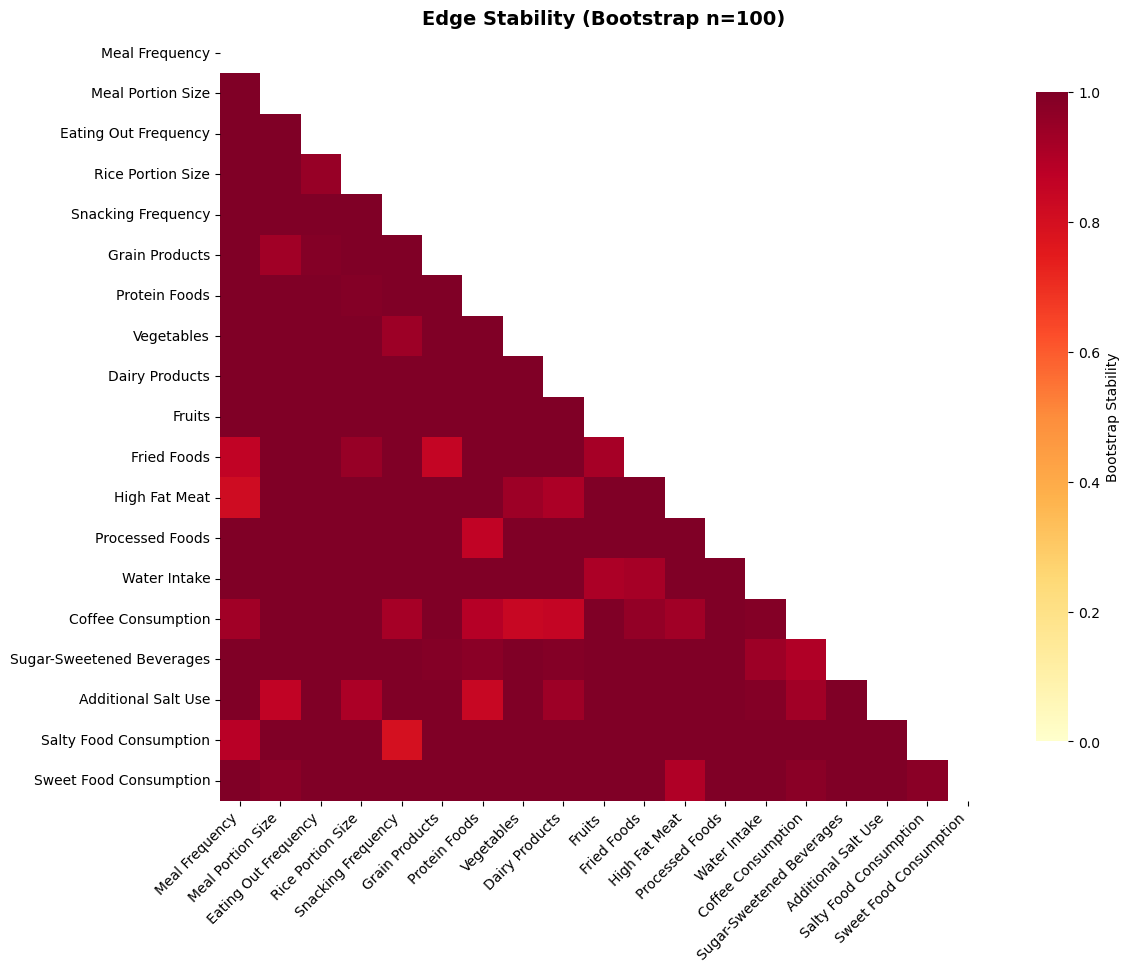


=== Stable Network Summary ===
Nodes: 19
Stable edges: 171
Average edge weight: 0.053
Connected components: 1


In [7]:
# Bootstrap analysis for network stability
print("=== Bootstrap Network Stability Analysis ===\n")

n_bootstrap = 100
n_samples = food_data_scaled.shape[0]
n_vars = food_data_scaled.shape[1]

# Store edge presence across bootstrap samples
edge_bootstrap_counts = np.zeros((n_vars, n_vars))

print(f"Running {n_bootstrap} bootstrap iterations...")
for b in range(n_bootstrap):
    if (b + 1) % 20 == 0:
        print(f"  Progress: {b+1}/{n_bootstrap}")
    
    # Resample with replacement
    bootstrap_indices = np.random.choice(n_samples, size=n_samples, replace=True)
    bootstrap_data = food_data_scaled[bootstrap_indices, :]
    
    # Fit Graphical Lasso
    try:
        gl_boot = GraphicalLassoCV(cv=3, max_iter=500, tol=1e-3, n_jobs=-1, alphas=5)
        gl_boot.fit(bootstrap_data)
        
        # Calculate partial correlations
        boot_precision = gl_boot.precision_
        boot_partial_corr = -boot_precision / np.sqrt(np.outer(np.diag(boot_precision), np.diag(boot_precision)))
        
        # Count significant edges (using the threshold from permutation test)
        boot_significant = np.abs(boot_partial_corr) > threshold
        np.fill_diagonal(boot_significant, False)
        
        edge_bootstrap_counts += boot_significant
    except:
        continue

# Calculate edge stability (proportion of bootstrap samples where edge appears)
edge_stability = edge_bootstrap_counts / n_bootstrap

print(f"\n=== Edge Stability Results ===")
print(f"Edges appearing in >90% of bootstrap samples: {np.sum(edge_stability > 0.9) // 2}")
print(f"Edges appearing in >75% of bootstrap samples: {np.sum(edge_stability > 0.75) // 2}")
print(f"Edges appearing in >50% of bootstrap samples: {np.sum(edge_stability > 0.50) // 2}")

# Filter network to stable edges only (appearing in >75% of bootstrap samples)
stable_threshold = 0.75
stable_edges = edge_stability > stable_threshold

print(f"\nUsing stability threshold: {stable_threshold} (edges must appear in >{stable_threshold*100:.0f}% of bootstrap samples)")
print(f"Stable edges: {np.sum(stable_edges) // 2}")

# Visualize edge stability
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(edge_stability, dtype=bool))
sns.heatmap(edge_stability, mask=mask, annot=False, cmap='YlOrRd', center=0.5,
            square=True, cbar_kws={"shrink": .8, "label": "Bootstrap Stability"},
            xticklabels=food_data_transformed.columns, yticklabels=food_data_transformed.columns,
            vmin=0, vmax=1)
plt.title(f'Edge Stability (Bootstrap n={n_bootstrap})', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Create stable network
G_stable = nx.Graph()

for i, food in enumerate(food_data_transformed.columns):
    G_stable.add_node(food)

stable_edge_weights = []
for i in range(n_vars):
    for j in range(i+1, n_vars):
        if stable_edges[i, j]:
            weight = abs(partial_corr_matrix[i, j])
            stability = edge_stability[i, j]
            G_stable.add_edge(food_data_transformed.columns[i], food_data_transformed.columns[j], 
                            weight=weight, stability=stability)
            stable_edge_weights.append(weight)

print(f"\n=== Stable Network Summary ===")
print(f"Nodes: {G_stable.number_of_nodes()}")
print(f"Stable edges: {G_stable.number_of_edges()}")
if stable_edge_weights:
    print(f"Average edge weight: {np.mean(stable_edge_weights):.3f}")
print(f"Connected components: {nx.number_connected_components(G_stable)}")

# Update G to use stable network
G = G_stable.copy()


=== Graphical Lasso를 이용한 정밀행렬 추정 ===
최적 alpha (정규화 파라미터): 0.0010
정밀행렬 크기: (19, 19)


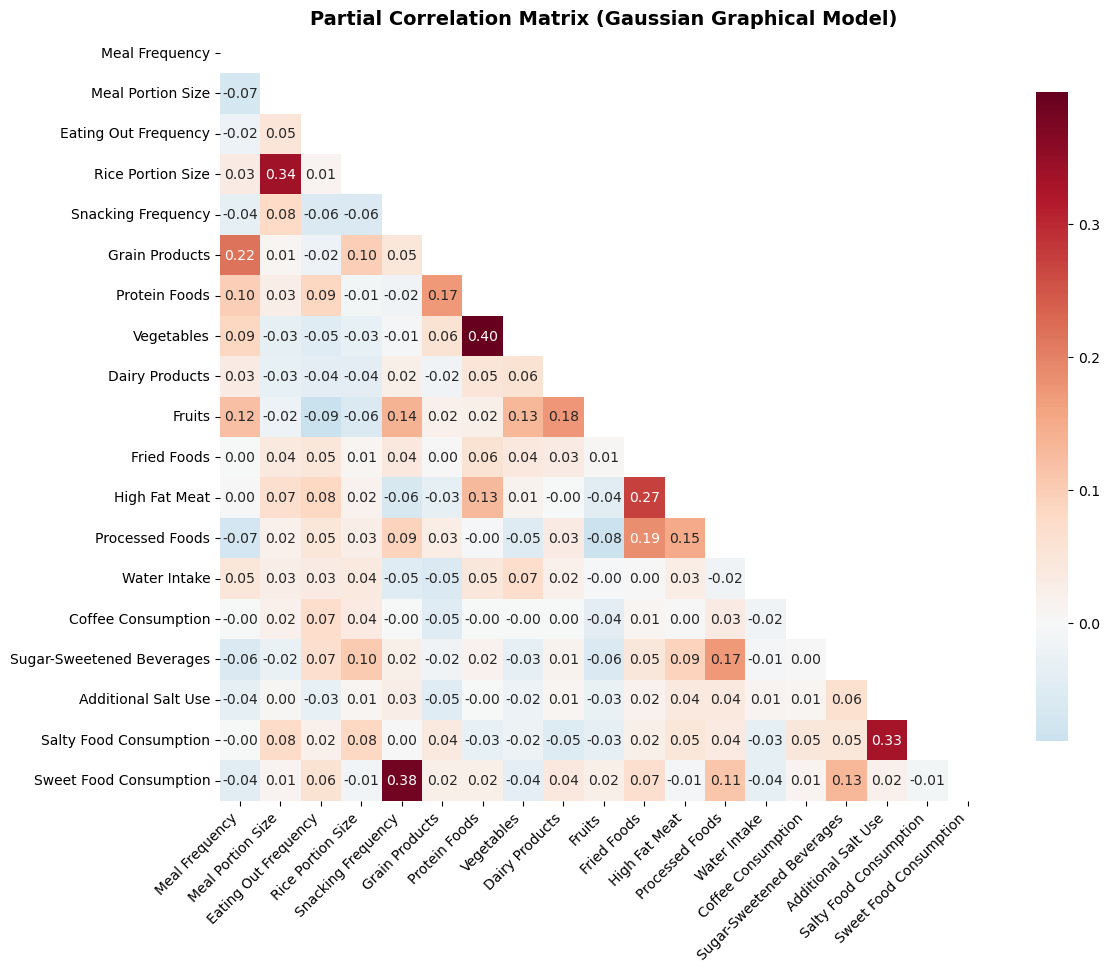

편상관계수 임계값: 0.05
유의한 엣지 수: 53
전체 가능한 엣지 수: 171
네트워크 밀도: 0.310
네트워크 생성 완료: 19개 노드, 53개 엣지
평균 엣지 가중치: 0.115
연결된 구성요소 수: 1


In [8]:
# Data standardization for GGM
scaler = StandardScaler()
food_data_scaled = scaler.fit_transform(food_data)
food_data_scaled_df = pd.DataFrame(food_data_scaled, columns=food_data.columns)

# Gaussian Graphical Model using Graphical Lasso
print("\n=== Graphical Lasso를 이용한 정밀행렬 추정 ===")
gl_cv = GraphicalLassoCV(cv=5, max_iter=1000, tol=1e-4, n_jobs=-1)
gl_cv.fit(food_data_scaled)

precision_matrix = gl_cv.precision_
partial_corr_matrix = -precision_matrix / np.sqrt(np.outer(np.diag(precision_matrix), np.diag(precision_matrix)))
np.fill_diagonal(partial_corr_matrix, 1)

print(f"최적 alpha (정규화 파라미터): {gl_cv.alpha_:.4f}")
print(f"정밀행렬 크기: {precision_matrix.shape}")

# 편상관계수 행렬 시각화
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(partial_corr_matrix, dtype=bool))
sns.heatmap(partial_corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            square=True, fmt='.2f', cbar_kws={"shrink": .8},
            xticklabels=food_data.columns, yticklabels=food_data.columns)
plt.title('Partial Correlation Matrix (Gaussian Graphical Model)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 통계적 유의성 검정을 위한 부분상관계수 임계값 설정
n_vars = food_data_scaled.shape[1]

threshold = 0.05
significant_edges = np.abs(partial_corr_matrix) > threshold
np.fill_diagonal(significant_edges, False)  # 대각선 제거

print(f"편상관계수 임계값: {threshold}")
print(f"유의한 엣지 수: {np.sum(significant_edges) // 2}")  # 대칭행렬이므로 2로 나눔
print(f"전체 가능한 엣지 수: {n_vars * (n_vars - 1) // 2}")
print(f"네트워크 밀도: {(np.sum(significant_edges) // 2) / (n_vars * (n_vars - 1) // 2):.3f}")

# 네트워크 그래프 생성
G = nx.Graph()

for i, food in enumerate(food_data.columns):
    G.add_node(food)

edge_weights = []
for i in range(n_vars):
    for j in range(i+1, n_vars):
        if significant_edges[i, j]:
            weight = abs(partial_corr_matrix[i, j])
            G.add_edge(food_data.columns[i], food_data.columns[j], weight=weight)
            edge_weights.append(weight)

print(f"네트워크 생성 완료: {G.number_of_nodes()}개 노드, {G.number_of_edges()}개 엣지")
print(f"평균 엣지 가중치: {np.mean(edge_weights):.3f}")
print(f"연결된 구성요소 수: {nx.number_connected_components(G)}")

## 4. 네트워크 그래프 생성 및 클러스터링

In [9]:
# Louvain 알고리즘을 사용한 커뮤니티 탐지
partitions = nx.community.louvain_communities(G, weight='weight', seed=42)
modularity = nx.community.modularity(G, partitions, weight='weight')

print(f"발견된 커뮤니티 수: {len(partitions)}")
print(f"모듈러리티: {modularity:.3f}")

cluster_dict = {}
for i, partition in enumerate(partitions):
    for node in partition:
        cluster_dict[node] = i

print("\n=== 클러스터별 구성 ===")
for i, partition in enumerate(partitions):
    central_node = max(partition, key=lambda x: G.degree(x, weight='weight'))
    print(f"클러스터 {i} (중심: {central_node}): {list(partition)}")

발견된 커뮤니티 수: 3
모듈러리티: 0.386

=== 클러스터별 구성 ===
클러스터 0 (중심: Rice Portion Size): ['Additional Salt Use', 'Salty Food Consumption', 'Meal Portion Size', 'Rice Portion Size']
클러스터 1 (중심: Protein Foods): ['Fruits', 'Meal Frequency', 'Dairy Products', 'Vegetables', 'Grain Products', 'Water Intake', 'Protein Foods']
클러스터 2 (중심: Processed Foods): ['Snacking Frequency', 'Fried Foods', 'Eating Out Frequency', 'High Fat Meat', 'Sweet Food Consumption', 'Sugar-Sweetened Beverages', 'Coffee Consumption', 'Processed Foods']


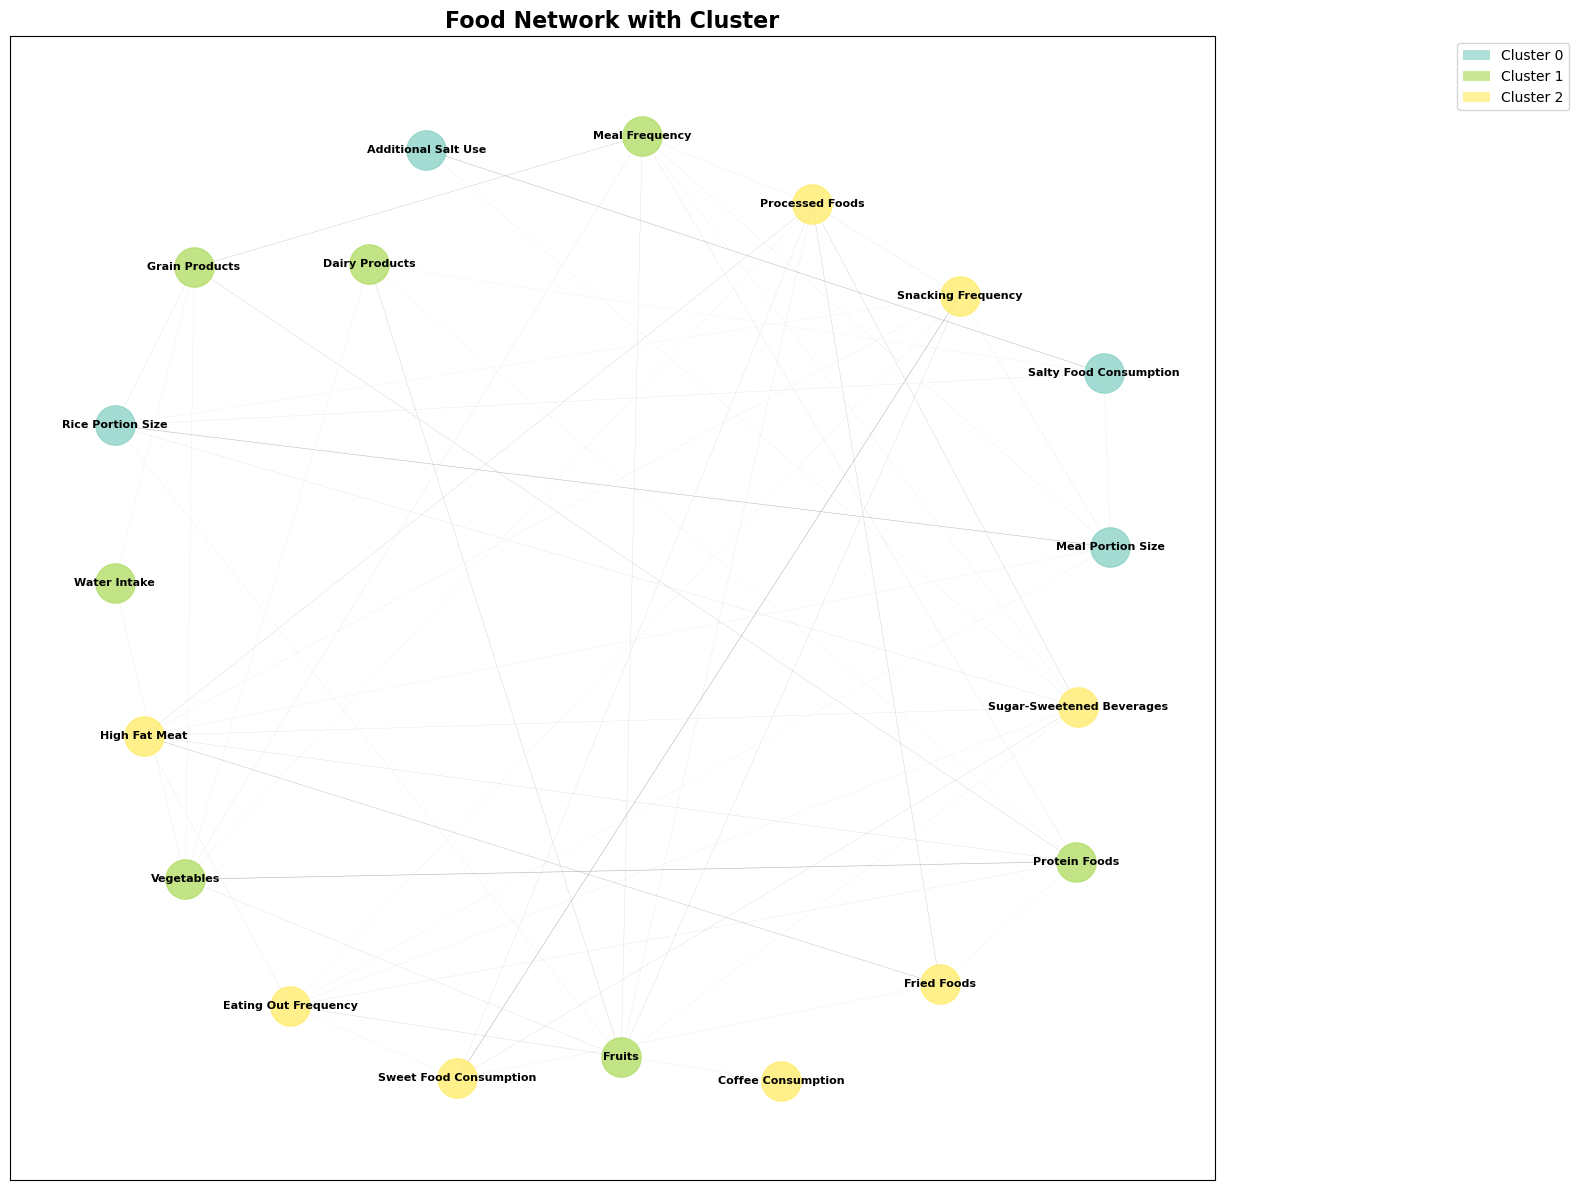

In [10]:
# 네트워크 시각화
plt.figure(figsize=(16, 12))

pos = nx.spring_layout(G, k=3, iterations=50, seed=42)
colors = plt.cm.Set3(np.linspace(0, 1, len(partitions)))
unique_clusters = sorted(set(cluster_dict.values()))

for cluster_id in unique_clusters:
    cluster_nodes = [node for node, c in cluster_dict.items() if c == cluster_id]
    nx.draw_networkx_nodes(G, pos, nodelist=cluster_nodes, 
                          node_color=[colors[cluster_id]], 
                          node_size=800, alpha=0.8)

if G.number_of_edges() > 0:
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, 
                          alpha=0.6, edge_color='gray')

nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title('Food Network with Cluster', fontsize=16, fontweight='bold')

legend_elements = [plt.Rectangle((0,0),1,1, fc=colors[i], alpha=0.7)
                  for i in range(len(unique_clusters))]
plt.legend(legend_elements, [f'Cluster {i}' for i in unique_clusters],
          loc='upper right', bbox_to_anchor=(1.3, 1))

plt.tight_layout()
plt.show()

In [11]:
from sklearn.decomposition import PCA

cluster_scores = {}
cluster_loadings = {}

unique_clusters = sorted(set(cluster_dict.values()))

for cluster_id in unique_clusters:
    cluster_foods = [food for food, c in cluster_dict.items() if c == cluster_id]
    
    # Multi-food clusters: Use PCA to create composite score
    if len(cluster_foods) > 1:
        # Use transformed data for PCA
        cluster_data = food_data_transformed[cluster_foods].astype(float)
        cluster_data = cluster_data.fillna(cluster_data.mean())
        
        scaler = StandardScaler()
        cluster_data_scaled = scaler.fit_transform(cluster_data)
        
        # PCA with 1 component to get cluster score
        pca = PCA(n_components=1)
        scores = pca.fit_transform(cluster_data_scaled)            
        cluster_scores[f'cluster_{cluster_id}'] = scores.flatten().astype(float)
        cluster_loadings[f'cluster_{cluster_id}'] = {
            'foods': cluster_foods,
            'loadings': dict(zip(cluster_foods, pca.components_[0])),
            'explained_variance': pca.explained_variance_ratio_[0],
            'interpretation': f'PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance'
        }
        
        print(f"  cluster {cluster_id}: {len(cluster_foods)} foods, "
                f"PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance")
        
    # Single-food clusters: Use food value directly
    else:
        single_data = food_data_transformed[cluster_foods[0]].fillna(food_data_transformed[cluster_foods[0]].mean())
        cluster_scores[f'cluster_{cluster_id}'] = single_data.values.astype(float)
        cluster_loadings[f'cluster_{cluster_id}'] = {
            'foods': cluster_foods,
            'loadings': {cluster_foods[0]: 1.0},
            'explained_variance': 1.0,
            'interpretation': 'Single food - 100% variance captured'
        }
        
        print(f"  cluster {cluster_id}: Single food ({cluster_foods[0]})")

cluster_scores_df = pd.DataFrame(cluster_scores)

for col in cluster_scores_df.columns:
    cluster_scores_df[col] = pd.to_numeric(cluster_scores_df[col], errors='coerce')

# Display loadings interpretation
print(f"\n=== PCA Loadings Interpretation ===")
for cluster, loading_info in cluster_loadings.items():
    if len(loading_info['foods']) > 1:
        print(f"\n{cluster}:")
        print(f"  {loading_info['interpretation']}")
        print("  Food contributions (loadings):")
        for food, loading in loading_info['loadings'].items():
            contribution = "high" if abs(loading) > 0.5 else "moderate" if abs(loading) > 0.3 else "low"
            print(f"    {food}: {loading:.3f} ({contribution} contribution)")

  cluster 0: 4 foods, PC1 explains 41.6% of variance
  cluster 1: 7 foods, PC1 explains 29.6% of variance
  cluster 2: 8 foods, PC1 explains 28.5% of variance

=== PCA Loadings Interpretation ===

cluster_0:
  PC1 explains 41.6% of variance
  Food contributions (loadings):
    Additional Salt Use: 0.452 (moderate contribution)
    Salty Food Consumption: 0.533 (high contribution)
    Meal Portion Size: 0.504 (high contribution)
    Rice Portion Size: 0.507 (high contribution)

cluster_1:
  PC1 explains 29.6% of variance
  Food contributions (loadings):
    Fruits: -0.348 (moderate contribution)
    Meal Frequency: -0.421 (moderate contribution)
    Dairy Products: -0.253 (low contribution)
    Vegetables: -0.503 (high contribution)
    Grain Products: -0.362 (moderate contribution)
    Water Intake: -0.140 (low contribution)
    Protein Foods: -0.483 (moderate contribution)

cluster_2:
  PC1 explains 28.5% of variance
  Food contributions (loadings):
    Snacking Frequency: 0.275 (low 

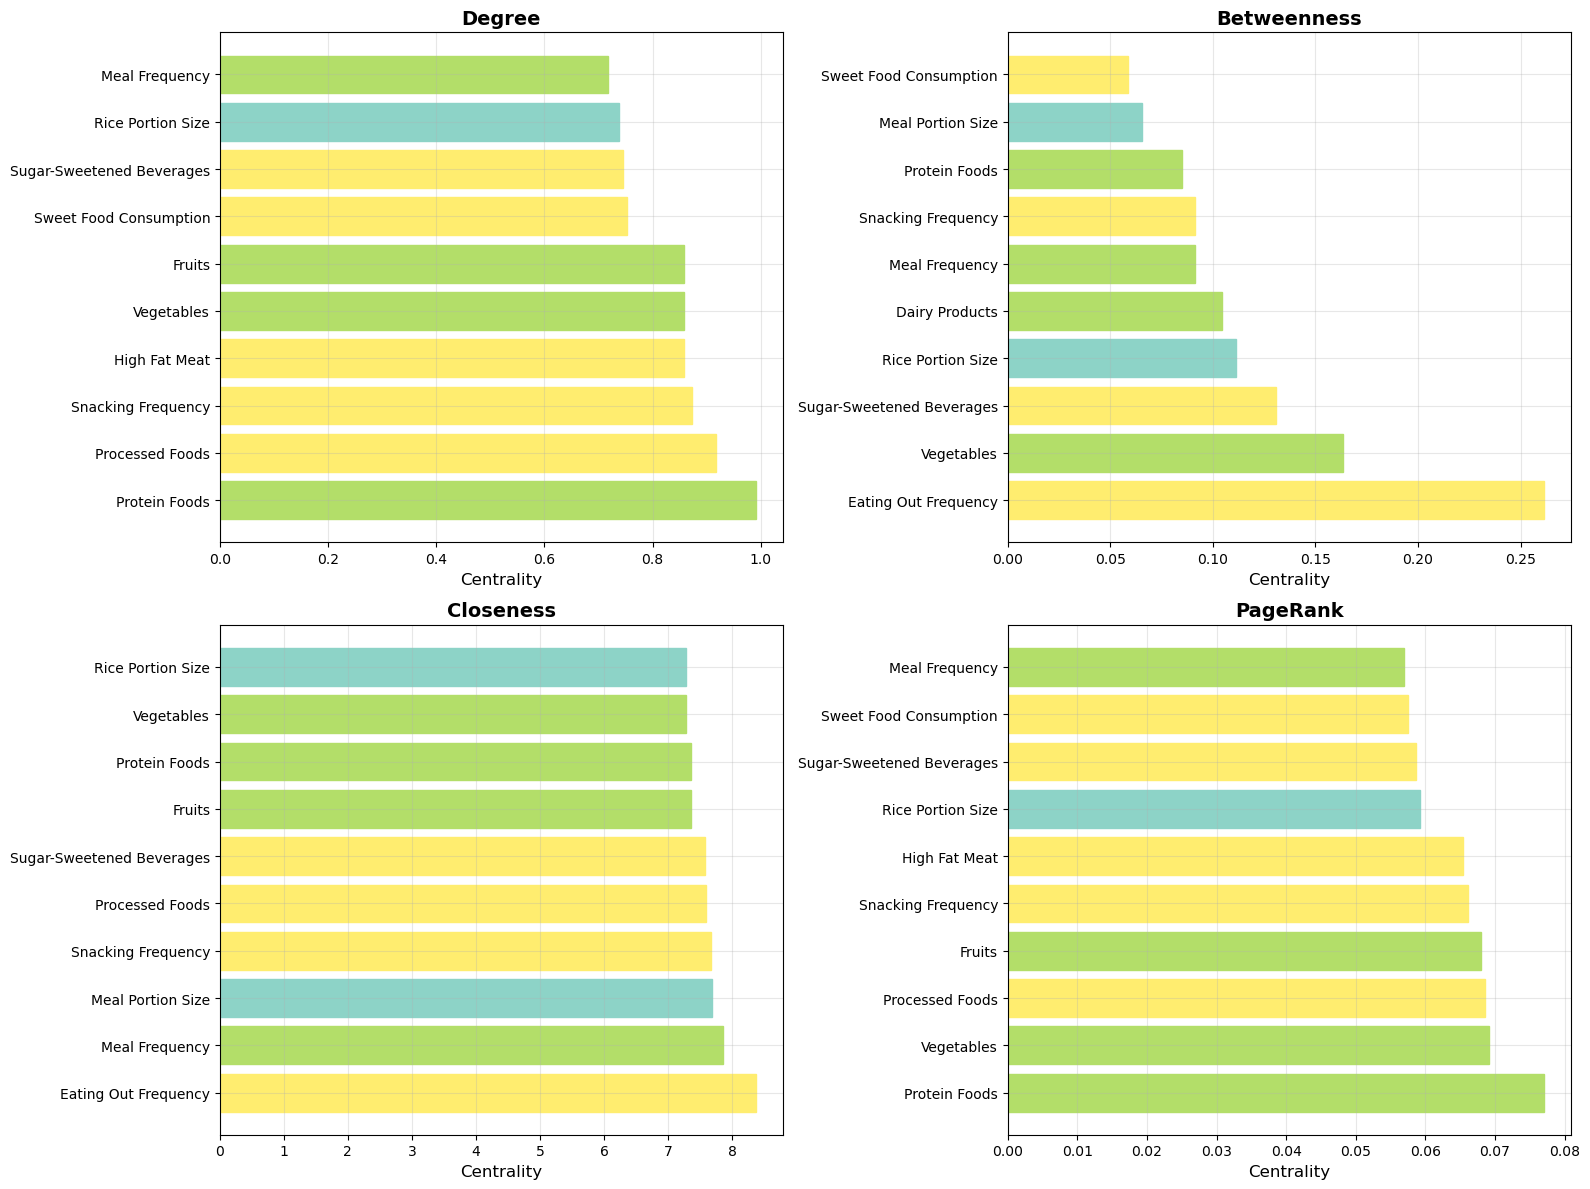

In [12]:
try:
    eigenvector_cent = nx.eigenvector_centrality(G, weight='weight', max_iter=2000, tol=1e-4)
except nx.PowerIterationFailedConvergence:
    try:
        eigenvector_cent = nx.eigenvector_centrality(G, max_iter=2000, tol=1e-4)
    except nx.PowerIterationFailedConvergence:
        eigenvector_cent = {node: 0.0 for node in G.nodes()}

centrality_data = {
    'Node': list(G.nodes()),
    'Degree': [G.degree(n, weight='weight') for n in G.nodes()],
    'Betweenness': list(nx.betweenness_centrality(G, weight='weight').values()),
    'Closeness': list(nx.closeness_centrality(G, distance='weight').values()),
    'Eigenvector': list(eigenvector_cent.values()),
    'PageRank': list(nx.pagerank(G, weight='weight').values())
}

centrality_df = pd.DataFrame(centrality_data)
centrality_df['Cluster'] = [cluster_dict[node] for node in centrality_df['Node']]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

centrality_measures = ['Degree', 'Betweenness', 'Closeness', 'PageRank']
for i, measure in enumerate(centrality_measures):
    ax = axes[i//2, i%2]
    top_nodes = centrality_df.nlargest(10, measure)
    
    bars = ax.barh(top_nodes['Node'], top_nodes[measure])
    
    for j, bar in enumerate(bars):
        cluster_id = top_nodes.iloc[j]['Cluster']
        bar.set_color(colors[cluster_id % len(colors)])
    
    ax.set_title(measure, fontsize=14, fontweight='bold')
    ax.set_xlabel('Centrality', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
for cluster_id in sorted(set(cluster_dict.values())):
    cluster_nodes = centrality_df[centrality_df['Cluster'] == cluster_id]
    
    if len(cluster_nodes) > 0:
        top_degree = cluster_nodes.loc[cluster_nodes['Degree'].idxmax()]
        top_between = cluster_nodes.loc[cluster_nodes['Betweenness'].idxmax()]
        
        print(f"\Cluster {cluster_id}:")
        print(f"  최고 연결도: {top_degree['Node']} ({top_degree['Degree']:.3f})")
        print(f"  최고 매개성: {top_between['Node']} ({top_between['Betweenness']:.3f})")

\Cluster 0:
  최고 연결도: Rice Portion Size (0.739)
  최고 매개성: Rice Portion Size (0.111)
\Cluster 1:
  최고 연결도: Protein Foods (0.991)
  최고 매개성: Vegetables (0.163)
\Cluster 2:
  최고 연결도: Processed Foods (0.918)
  최고 매개성: Eating Out Frequency (0.261)


## 5. 클러스터 점수 계산

In [14]:
from sklearn.decomposition import PCA

cluster_scores = {}
cluster_loadings = {}

unique_clusters = sorted(set(cluster_dict.values()))

for cluster_id in unique_clusters:
    cluster_foods = [food for food, c in cluster_dict.items() if c == cluster_id]
    
    # Multi-food clusters: Use PCA to create composite score
    if len(cluster_foods) > 1:
        cluster_data = food_data[cluster_foods].astype(float)
        cluster_data = cluster_data.fillna(cluster_data.mean())
        
        scaler = StandardScaler()
        cluster_data_scaled = scaler.fit_transform(cluster_data)
        
        # PCA with 1 component to get cluster score
        pca = PCA(n_components=1)
        scores = pca.fit_transform(cluster_data_scaled)            
        cluster_scores[f'cluster_{cluster_id}'] = scores.flatten().astype(float)
        cluster_loadings[f'cluster_{cluster_id}'] = {
            'foods': cluster_foods,
            'loadings': dict(zip(cluster_foods, pca.components_[0])),
            'explained_variance': pca.explained_variance_ratio_[0],
            'interpretation': f'PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance'
        }
        
        print(f"  cluster {cluster_id}: {len(cluster_foods)} foods, "
                f"PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance")
        
    # Single-food clusters: Use food value directly
    else:
        single_data = food_data[cluster_foods[0]].fillna(food_data[cluster_foods[0]].mean())
        cluster_scores[f'cluster_{cluster_id}'] = single_data.values.astype(float)
        cluster_loadings[f'cluster_{cluster_id}'] = {
            'foods': cluster_foods,
            'loadings': {cluster_foods[0]: 1.0},
            'explained_variance': 1.0,
            'interpretation': 'Single food - 100% variance captured'
        }
        
        print(f"  cluster {cluster_id}: Single food ({cluster_foods[0]})")

cluster_scores_df = pd.DataFrame(cluster_scores)

for col in cluster_scores_df.columns:
    cluster_scores_df[col] = pd.to_numeric(cluster_scores_df[col], errors='coerce')

# Display loadings interpretation
print(f"\n=== PCA Loadings Interpretation ===")
for cluster, loading_info in cluster_loadings.items():
    if len(loading_info['foods']) > 1:
        print(f"\n{cluster}:")
        print(f"  {loading_info['interpretation']}")
        print("  Food contributions (loadings):")
        for food, loading in loading_info['loadings'].items():
            contribution = "high" if abs(loading) > 0.5 else "moderate" if abs(loading) > 0.3 else "low"
            print(f"    {food}: {loading:.3f} ({contribution} contribution)")


  cluster 0: 4 foods, PC1 explains 41.6% of variance
  cluster 1: 7 foods, PC1 explains 29.5% of variance
  cluster 2: 8 foods, PC1 explains 28.3% of variance

=== PCA Loadings Interpretation ===

cluster_0:
  PC1 explains 41.6% of variance
  Food contributions (loadings):
    Additional Salt Use: 0.452 (moderate contribution)
    Salty Food Consumption: 0.534 (high contribution)
    Meal Portion Size: 0.504 (high contribution)
    Rice Portion Size: 0.507 (high contribution)

cluster_1:
  PC1 explains 29.5% of variance
  Food contributions (loadings):
    Fruits: -0.350 (moderate contribution)
    Meal Frequency: -0.416 (moderate contribution)
    Dairy Products: -0.257 (low contribution)
    Vegetables: -0.505 (high contribution)
    Grain Products: -0.359 (moderate contribution)
    Water Intake: -0.140 (low contribution)
    Protein Foods: -0.484 (moderate contribution)

cluster_2:
  PC1 explains 28.3% of variance
  Food contributions (loadings):
    Snacking Frequency: 0.276 (low 

In [15]:
tertile_data = {}
for col in cluster_scores_df.columns:
    tertile_data[f'{col}_tertile'] = pd.qcut(cluster_scores_df[col], q=3, labels=['T1', 'T2', 'T3'], duplicates='drop')
tertile_df = pd.DataFrame(tertile_data)
tertile_df.head()

,cluster_0_tertile,cluster_1_tertile,cluster_2_tertile
0,T3,T3,T1
1,T1,T2,T2
2,T2,T1,T1
3,T2,T2,T1
4,T3,T2,T2


## 6. 대사증후군 연관성 분석

In [16]:
analysis_data = pd.concat([combined_data.reset_index(drop=True),
                            cluster_scores_df.reset_index(drop=True),
                            tertile_df.reset_index(drop=True)], axis=1)

metabolic_results = {}
metabolic_vars = list(health_vars.columns) + list(mets_components.columns)
for cluster in cluster_scores_df.columns:
    tertile_col = f'{cluster}_tertile'
    if tertile_col not in analysis_data.columns:
        continue
    
    cluster_results = {}
    
    for var in metabolic_vars:
        groups = [analysis_data[analysis_data[tertile_col] == t][var].dropna().values
                    for t in ['T1', 'T2', 'T3']]
        groups = [g for g in groups if len(g) > 0]
        
        if len(groups) >= 2:
            f_stat, p_value = stats.f_oneway(*groups)
            
            means = {}
            for t in ['T1', 'T2', 'T3']:
                tertile_data = analysis_data[analysis_data[tertile_col] == t][var].dropna()
                if len(tertile_data) > 0:
                    means[t] = tertile_data.mean()
                else:
                    means[t] = np.nan
            
            cluster_results[var] = {
                'f_statistic': f_stat,
                'p_value': p_value,
                'means': means,
                'significant': p_value < 0.05
            }
        
    metabolic_results[cluster] = cluster_results
    
# 유의한 결과 정리
significant_results = []
for cluster, cluster_results in metabolic_results.items():
    for var, var_results in cluster_results.items():
        if var_results['significant']:
            trend = 'Increasing' if var_results['means']['T3'] > var_results['means']['T1'] else 'Decreasing'
            significant_results.append({
                'cluster': cluster,
                'Variable': var,
                'F_statistic': var_results['f_statistic'],
                'P_value': var_results['p_value'],
                'T1_mean': var_results['means']['T1'],
                'T2_mean': var_results['means']['T2'],
                'T3_mean': var_results['means']['T3'],
                'Trend': trend
            })

results_df = pd.DataFrame(significant_results)
display(results_df.round(4))

,cluster,Variable,F_statistic,P_value,T1_mean,T2_mean,T3_mean,Trend
0,cluster_0,BMI,809.6505,0.0000,22.4071,23.3815,24.8510,Increasing
1,cluster_0,SBP,68.6814,0.0000,116.3291,117.6149,119.2800,Increasing
2,cluster_0,DBP,106.3543,0.0000,74.5755,75.8625,77.2321,Increasing
3,cluster_0,TC,15.4450,0.0000,202.0946,201.8177,205.4382,Increasing
4,cluster_0,TG,297.4439,0.0000,93.9839,107.4970,125.4818,Increasing
5,cluster_0,LDL,56.4382,0.0000,125.4465,127.4855,132.2652,Increasing
6,cluster_0,HDL,267.6178,0.0000,57.6232,54.6966,52.2146,Decreasing
7,cluster_0,FG,47.4967,0.0000,97.6283,99.2118,100.7009,Increasing
8,cluster_0,WC,413.5997,0.0000,0.2320,0.3242,0.4721,Increasing
9,cluster_0,U_BP,41.7327,0.0000,0.3240,0.3627,0.4025,Increasing


## 9. 종합 결과 요약

In [17]:
summary_data = []

for cluster_id in sorted(set(cluster_dict.values())):
    cluster_foods = [food for food, c in cluster_dict.items() if c == cluster_id]
    central_food = max(cluster_foods, key=lambda x: nx.degree_centrality(G).get(x, 0))
    
    cluster_name = f'cluster_{cluster_id}'
    
    if cluster_name in metabolic_results:
        cluster_results = metabolic_results[cluster_name]
        significant_associations = [var for var, result in cluster_results.items() if result['significant']]
        
        beneficial_effects = 0
        harmful_effects = 0
        
        for var, result in cluster_results.items():
            if result['significant']:
                t1_mean = result['means']['T1']
                t3_mean = result['means']['T3']
                
                # 건강에 유익한 방향인지 판단
                if var in ['HDL']:  # HDL은 높을수록 좋음
                    if t3_mean > t1_mean:
                        beneficial_effects += 1
                    else:
                        harmful_effects += 1
                elif var in ['SBP', 'DBP', 'TC', 'TG', 'LDL', 'FG']:  # 낮을수록 좋음
                    if t3_mean < t1_mean:
                        beneficial_effects += 1
                    else:
                        harmful_effects += 1
        
        # 전반적 효과 판단
        if beneficial_effects > harmful_effects:
            overall_effect = '유익함'
        elif harmful_effects > beneficial_effects:
            overall_effect = '유해함'
        else:
            overall_effect = '중성'
    else:
        significant_associations = []
        overall_effect = '연관성 없음'
    
    summary_data.append({
        '클러스터': f'클러스터 {cluster_id}',
        '중심식품': central_food,
        '구성식품': ', '.join(cluster_foods),
        '식품수': len(cluster_foods),
        '유의한연관성수': len(significant_associations),
        '주요연관변수': ', '.join(significant_associations[:3]),  # 상위 3개만 표시
        '전반적효과': overall_effect
    })
    
summary_table = pd.DataFrame(summary_data)

print("\n=== 식품 네트워크 분석 종합 결과 ===")
display(summary_table)


=== 식품 네트워크 분석 종합 결과 ===


,클러스터,중심식품,구성식품,식품수,유의한연관성수,주요연관변수,전반적효과
0,클러스터 0,Meal Portion Size,"Additional Salt Use, Salty Food Consumption, M...",4,14,"BMI, SBP, DBP",유해함
1,클러스터 1,Fruits,"Fruits, Meal Frequency, Dairy Products, Vegeta...",7,8,"SBP, TC, TG",유해함
2,클러스터 2,Eating Out Frequency,"Snacking Frequency, Fried Foods, Eating Out Fr...",8,13,"BMI, SBP, DBP",유해함


In [18]:
print("\n=== 주요 발견사항 ===")
print("\n1. 네트워크 구조:")
print(f"   - 총 {len(set(cluster_dict.values()))}개의 식품 네트워크 발견")
print(f"   - 네트워크 모듈러리티: {nx.community.modularity(G, partitions, weight='weight'):.3f}")

print("\n2. 건강 효과가 있는 네트워크:")
beneficial_networks = summary_table[summary_table['전반적효과'] == '유익함']
for _, row in beneficial_networks.iterrows():
    print(f"   - {row['클러스터']} ({row['중심식품']}): {row['주요연관변수']}")

print("\n3. 주의가 필요한 네트워크:")
harmful_networks = summary_table[summary_table['전반적효과'] == '유해함']
for _, row in harmful_networks.iterrows():
    print(f"   - {row['클러스터']} ({row['중심식품']}): {row['주요연관변수']}")


=== 주요 발견사항 ===

1. 네트워크 구조:
   - 총 3개의 식품 네트워크 발견
   - 네트워크 모듈러리티: 0.386

2. 건강 효과가 있는 네트워크:

3. 주의가 필요한 네트워크:
   - 클러스터 0 (Meal Portion Size): BMI, SBP, DBP
   - 클러스터 1 (Fruits): SBP, TC, TG
   - 클러스터 2 (Eating Out Frequency): BMI, SBP, DBP
